# Load reviews dataset

# Reviews Feature Engineering

This notebook analyzes Airbnb review data and creates review-based features at the listing level.

The objective is to transform individual guest reviews into aggregated variables that can later be used for price prediction and listing analysis.

Main features created:
- review_count: total number of reviews per listing
- avg_review_length: average review length per listing
- latest_review_date: most recent review date per listing

In [56]:
#setup
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/santiagotawata/Desktop/airbnb-rome-analysis


In [57]:
reviews = pd.read_csv(
    "../data/reviews.csv.gz",
    compression="gzip"
)

In [58]:
reviews.info()
reviews.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477671 entries, 0 to 2477670
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   listing_id     int64 
 1   id             int64 
 2   date           object
 3   reviewer_id    int64 
 4   reviewer_name  object
 5   comments       object
dtypes: int64(3), object(3)
memory usage: 113.4+ MB


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2737,24343517,2014-12-26,24333039,Raphaell,"This spot was in a great and nice area,walking..."
1,2737,24966779,2015-01-04,10493776,Ia,"Elif was really very helpful, while arranging ..."
2,2737,29770086,2015-04-12,29630601,Julia,"Elif's flat is spacious, clean, and had everyt..."
3,2737,30477570,2015-04-22,31215535,Sevil,I had a wonderful time staying with Elif and h...
4,2737,31659336,2015-05-08,1959813,Suzy,"Elif was a brilliant host, with an exceptional..."


## Review Length Feature

Review length is measured as the number of words contained in each review comment.

This variable is used as a proxy for guest engagement and review detail.

In [59]:
reviews["comments"] = reviews["comments"].fillna("")
reviews["review_length"] = reviews["comments"].str.split().str.len()

## Aggregate Reviews at Listing Level

Individual reviews are aggregated into listing-level features.

For each listing we calculate:
- Total number of reviews
- Average review length

In [60]:
review_features = (
    reviews
    .groupby("listing_id")
    .agg(
        review_count=("comments", "count"),
        avg_review_length=("review_length", "mean")
    )
    .reset_index()
)

review_features.head()

,listing_id,review_count,avg_review_length
0,2737,5,51.800000
1,11834,302,74.165563
2,12398,85,84.658824
3,19965,195,44.953846
4,20534,50,60.200000


The resulting dataset contains one observation per listing and summarizes review activity across all reviews associated with that listing.

In [61]:
reviews.columns.tolist()

['listing_id',
 'id',
 'date',
 'reviewer_id',
 'reviewer_name',
 'comments',
 'review_length']

In [62]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477671 entries, 0 to 2477670
Data columns (total 7 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   listing_id     int64 
 1   id             int64 
 2   date           object
 3   reviewer_id    int64 
 4   reviewer_name  object
 5   comments       object
 6   review_length  int64 
dtypes: int64(4), object(3)
memory usage: 132.3+ MB


## Descriptive Statistics

Summary statistics are generated to understand the distribution of the engineered review features.

In [63]:
review_features["review_count"].describe()

count    32827.000000
mean        75.476620
std        110.387114
min          1.000000
25%          8.000000
50%         33.000000
75%         94.000000
max       3080.000000
Name: review_count, dtype: float64

In [64]:
review_features["avg_review_length"].describe()

count    32827.000000
mean        43.382865
std         17.758099
min          0.000000
25%         33.947710
50%         42.150000
75%         50.843710
max        300.000000
Name: avg_review_length, dtype: float64

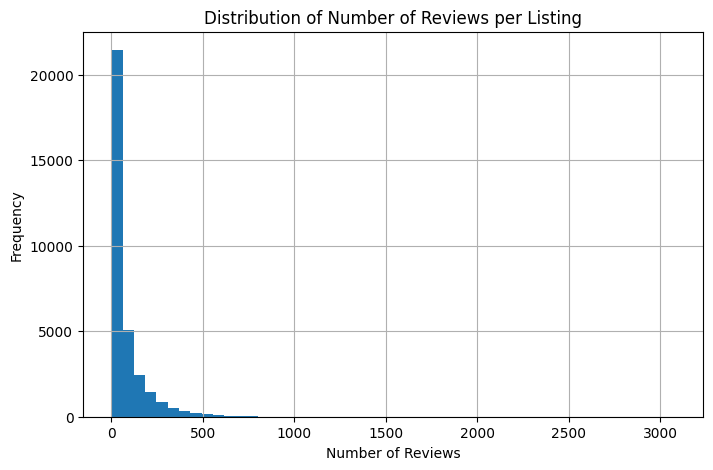

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
review_features["review_count"].hist(bins=50)
plt.title("Distribution of Number of Reviews per Listing")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

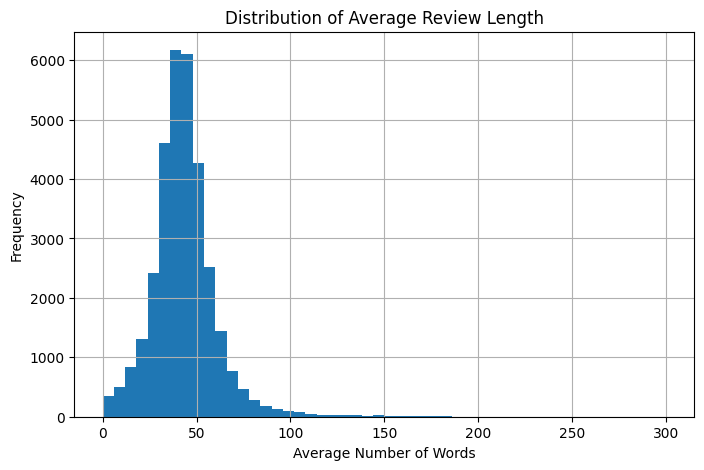

In [66]:
plt.figure(figsize=(8,5))
review_features["avg_review_length"].hist(bins=50)
plt.title("Distribution of Average Review Length")
plt.xlabel("Average Number of Words")
plt.ylabel("Frequency")
plt.show()

Review-based features were engineered by aggregating individual reviews at the listing level. For each listing, the total number of reviews (review_count) and the average review length (avg_review_length) were calculated. Review length was measured as the number of words contained in each review comment.

In [67]:
latest_review = (
    reviews.groupby("listing_id")["date"]
    .max()
    .reset_index(name="latest_review_date")
)

latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2026-06-07
2,12398,2025-08-01
3,19965,2026-06-13
4,20534,2022-11-22


## Latest Review Date

The most recent review date is extracted for each listing.

This feature may provide information about listing activity and recency of guest interactions.

In [68]:
reviews["date"] = pd.to_datetime(reviews["date"])

In [69]:
latest_review = (
    reviews.groupby("listing_id")["date"]
    .max()
    .reset_index(name="latest_review_date")
)

add lastest_review to the review_features data frame

In [70]:
review_features = review_features.merge(
    latest_review,
    on="listing_id",
    how="left"
)

In [71]:
latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2026-06-07
2,12398,2025-08-01
3,19965,2026-06-13
4,20534,2022-11-22


In [72]:
latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2026-06-07
2,12398,2025-08-01
3,19965,2026-06-13
4,20534,2022-11-22


## Save Engineered Features

The aggregated review features are saved for later use in the modeling stage.

In [73]:
review_features.to_csv(
    "../data/review_features.csv",
    index=False
)

print("Review features saved")

Review features saved
